# Influence of mass-balance parameters on glacier runoff

In this notebook, we will calabrate the mass-balance parameters in the OGGM, these parameters will then be used to calculate the components of the runoff and the runoff variable itself. These variables will then be investigated to understand sensitvity against the calibrated parameters.

For more information on the calibration methods, we would recommend the tutorial on mass-balance calibration [massbalance_calibration.ipynb](https://tutorials.oggm.org/stable/notebooks/tutorials/massbalance_calibration.html). Here our focus is how these impact runoff, this work has been motivated by the Wimberly et al paper [Inter-model differences in 21st centry glacier runoff for the world's major river basins](https://tc.copernicus.org/articles/19/1491/2025/).

In this notebook we will:
1. Use the OGGM scalar calibration method
2. Show how users can calibrate parameters and use these for runoff outputs to understand impact of parameter changes.
3. Investigate variable sensitivity to the calibrations.

## Set Up

First install required packages to run this tutorial. 

We will be using level 4 data to allow for the dynamical spinup and the calibration capabilities.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import oggm
from oggm import cfg, utils, workflow, tasks
import xarray as xr
from oggm.core import massbalance
from oggm.core.massbalance import mb_calibration_from_scalar_mb

In [3]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-ro', reset=True)
cfg.PARAMS['store_model_geometry'] = True

2025-11-18 10:08:08: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-11-18 10:08:08: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-11-18 10:08:08: oggm.cfg: Multiprocessing: using all available processors (N=22)
2025-11-18 10:08:09: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.


We start from a well known glacier in the Austrian Alps, Hintereisferner. But you can choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv)

In [4]:
# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

2025-11-18 10:08:09: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2025-11-18 10:08:09: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


## Generating the Hydrological and Glaciological outputs

The pre-processed directories don't automatically have hydrological outputs, so lets run the `run_with_hydro` task below to calculate these! This requires a dynamical spinup, let's choose the time period 2000-2020.

In [5]:
# file identifier where the model output is saved
file_id = '_default'

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # which climate scenario? See following notebook for other examples
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     init_model_yr=2000,  # Start from spinup year 2000
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix='_default')) as ds:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds = ds.isel(time=slice(0, -1)).load()

Now that we have the hydrological and glaciological outputs for our desired time period, lets calculate the total runoff for the glacier. There are four key variables that form the total runoff when summed together, and the process to calculate the runoff can be seen below.

The total runoff from the glacier is:
`runoff` = `melt_off_glacier` + `melt_on_glacier` + `liq_prcp_off_glacier` + `liq_prcp_on_glacier`


The figure below shows the runoff for the default calibrated parameters.

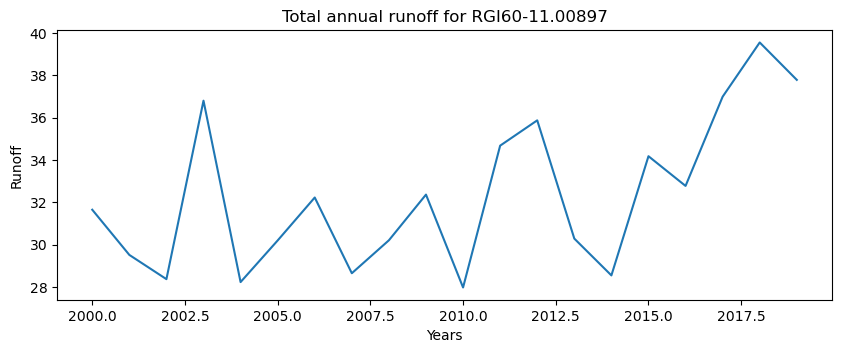

In [6]:
sel_vars = [v for v in ds.variables if 'month_2d' not in ds[v].dims]
df_annual = ds[sel_vars].to_dataframe()

# These summed variabels give the total runoff from the glacier
runoff_vars = ['melt_off_glacier', 'melt_on_glacier','liq_prcp_off_glacier', 'liq_prcp_on_glacier']

# Convert them to megatonnes (instead of kg)
df_runoff = df_annual[runoff_vars] * 1e-9
fig, ax = plt.subplots(figsize=(10, 3.5), sharex=True)
df_runoff.sum(axis=1).plot(ax=ax);
plt.ylabel('Runoff'); plt.xlabel('Years'); plt.title(f'Total annual runoff for {rgi_id}');


This was done with the following parameter set:

In [7]:
gdir_hef.read_json('mb_calib')

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 4.9206879441503215,
 'prcp_fac': 3.533570332820593,
 'temp_bias': 1.7583130779353044,
 'reference_mb': -1100.3,
 'reference_mb_err': 171.8,
 'reference_period': '2000-01-01_2020-01-01',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

## Parameter Calibration

The mass-balance parameters at Level 4 are pre-calibrated automatically by the OGGM and stored in the dataframe. However there are flexible mass-balance calibration schemes in the OGGM.

In this tutorial, our aim is to calibrate the mass-balance parameters and investigate the impact that this calibration has on the run-off. In the OGGM we can currently (at the time of writing this tutorial October 2025) only calibrate the melt_f, prcp_fac and temp_bias parameters. We will calibrate these parameters using the **scalar mass balance** method, and investigate the relationship with the runoff components and the total runoff output.

### **Calibration:** Scalar Mass Balance Calibration

Firstly comparing the mass balances below for in-situ observations and the default calibrated parameters. To understand the current behaviour of the mass balance output.


Now let's experiment by calibrating the parameters: these parameters are the melt factor (`melt_f`), the precipitation factor (`prcp_fac`) and the temperature bias (`temp_bias`). We will calibrate each parameter and permutations of the calibrations:
1. Just calibrating `melt_f`
2. Just calibrating `prcp_fac`
3. Just calibrating `temp_bias`
4. Calibrating `melt_f` and `prcp_fac`
5. Calibrating `prcp_fac` and `temp_bias`
6. Calibrating `melt_f` and `temp_bias`
7. Calibrating all parameters; `melt_f`, `prcp_fac` and `temp_bias`

The next calibration section will be relatively repetative, but take note of the parameters being calibrated and the inputs being used in the calibration process.

We will start the calibration by just calibrating the model the `melt_f` paramater.

<div class="alert alert-info">
    <b>
        Note: In the OGGM Scalar Calibration method, even when all parameters are nominated for calibration, they may not reach the calibration stage. The OGGM works by calibrating one parameter at a time, only moving onto the next when the previous parameter calibration cannot reach the desired target. In the tutorial below, we will see the result of this in action with usually only the first parameter being calibrated, even if all parameters are nominated for calibration.
    </b>
</div>

### Single Parameter Calibration

Fetch the reference mass balance we want to calibrate to from the geodetic mass-balance data, this is the data from Hugonnet et al 2021:

In [8]:
ref_mb_df = utils.get_geodetic_mb_dataframe().loc[gdir_hef.rgi_id]
ref_mb_df = ref_mb_df.loc[ref_mb_df['period'] == cfg.PARAMS['geodetic_mb_period']].iloc[0]
# dmdtda: in meters water-equivalent per year -> we convert to kg m-2 yr-1
ref_mb = ref_mb_df['dmdtda'] * 1000
ref_mb

-1100.3

Now we will calibrate with the scalar mass balance and use its default calibration setting. This is just calibrating the `melt_f` parameter:

In [9]:
# Just calibrate the melt_f parameter
calib_param_melt_f = mb_calibration_from_scalar_mb(gdir_hef,
                                                   ref_mb = ref_mb,
                                                   ref_period=cfg.PARAMS['geodetic_mb_period'],
                                                   overwrite_gdir=True)

# Creating a mass balance data frame to store the results
mbdf= pd.DataFrame(index = np.arange(2000,2020,1))

# Adding the mass balance model with the new calibration
mbmod = massbalance.MonthlyTIModel(gdir_hef)
fls = gdir_hef.read_pickle('inversion_flowlines')
mbdf['melt_f_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index)

calib_param_melt_f

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 9.059478188653333,
 'prcp_fac': 3.357136316271367,
 'temp_bias': 0,
 'reference_mb': -1100.3,
 'reference_mb_err': None,
 'reference_period': '2000-01-01_2020-01-01',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

We can see the parameters above, we will use the run_with_hydro task to gather the hydrological outputs. We will now calculate the runoff from the calabrated parameters.

In [10]:
# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
file_id = '_melt_f'

tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                    run_task=tasks.run_from_climate_data,  # running from observed climate data
                    ys=2000,  # Period which we will average and constantly repeat
                    init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                    init_model_yr=2000, # Start from spinup year 2000
                    store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                    output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_melt_f:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_melt_f = ds_melt_f.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_melt_f.variables if 'month_2d' not in ds_melt_f[v].dims]
df_annual_melt_f = ds_melt_f[sel_vars].to_dataframe()


Now calibrating the precipitation factor variable, `prcp_fac`. Here we fix the `melt_f` and the `temp_bias` and then calibrate the precipitation factor accordingly, this will ensure that the reference average mass balance will be matched.

In [11]:
# Just calibrate the prcp_fac parameter
calib_param_prcp_fac = mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb,
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='prcp_fac',
                              overwrite_gdir=True)

file_id = '_prcp_fac'

# Adding the mass balance model with the new calibration
mbmod = massbalance.MonthlyTIModel(gdir_hef)
fls = gdir_hef.read_pickle('inversion_flowlines')
mbdf['prcp_fac_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_yr=2000, # Start from spinup year 2000
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_prcp_fac:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_prcp_fac = ds_prcp_fac.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_prcp_fac.variables if 'month_2d' not in ds_prcp_fac[v].dims]
df_annual_prcp_fac = ds_prcp_fac[sel_vars].to_dataframe()

calib_param_prcp_fac

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 5.0,
 'prcp_fac': 1.016447639835006,
 'temp_bias': 0,
 'reference_mb': -1100.3,
 'reference_mb_err': None,
 'reference_period': '2000-01-01_2020-01-01',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

Note here that now the `melt_f` is lower than before, and the `prcp_fac` is now lowered in calibration so the average reference mass-balance can be matched.

Now calibrating the temperature bias parameter, `temp_bias`. Here we now fix the `melt_f` and `prcp_fac` to the default values, and calibrate the `temp_bias` to match the average reference mass-balance:

In [12]:
# Just calibrate the temp_bias parameters
temp_bias_calib = mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb,
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='temp_bias',
                              overwrite_gdir=True)

file_id = '_temp_bias'

# Adding the mass balance model with the new calibration
mbmod = massbalance.MonthlyTIModel(gdir_hef)
fls = gdir_hef.read_pickle('inversion_flowlines')
mbdf['temp_bias_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_yr=2000, # Start from spinup year 2000
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_temp_bias:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_temp_bias = ds_temp_bias.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_temp_bias.variables if 'month_2d' not in ds_temp_bias[v].dims]
df_annual_temp_bias = ds_temp_bias[sel_vars].to_dataframe()

temp_bias_calib

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 5.0,
 'prcp_fac': 3.357136316271367,
 'temp_bias': 1.6617639899008794,
 'reference_mb': -1100.3,
 'reference_mb_err': None,
 'reference_period': '2000-01-01_2020-01-01',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

Now both `melt_f` and `prcp_fac` are fixed to their default values. These are both on the lower-end to what they have been calibrated to previously when `temp_bias` is fixed. Since both of these parameters are slightly lower, the `temp_bias` is now calibrated to be higher than 0 to match the average reference mass-balance.

### Calibrating permutations of two parameters:

In `mb_calibration_from_scalar_mb` in the OGGM, calibrating two parameters works as the following:
1. Set calibrate_param1 and calibrate_param2.
2. The method fixes the third parameter that has not been set.
3. The method then fixes the parameter set to calibrate_param2 and calibrates calibrate_param1.
4. If the parameter set to calibrate_param1 can find a solution with just the one parameter, the calibration will stop.
5. If the parameter set to calibrate_param1 cannot find a solution with just one parameter alone, the method will fix the parameter to either its upper or lower limit (whichever is closer to a solution) and then move onto calibrating the parameter set to calibrate_param2.
6. If a solution is found with the second calibration attempt, the calibration will stop.
7. If no solution is found with either parameter calibrated, an error will raise and the calibration will stop with no solution found.

Now we will be using this technique to calibrate two parameters.

Now calibrating `melt_f` and `prcp_fac`:

In [13]:
# Calibrating the melt_f and prcp_fac parameters together
mf_pf_calibration = mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb,
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='melt_f',
                              calibrate_param2='prcp_fac',
                              overwrite_gdir=True)


file_id = '_mf_pf'

# Adding the mass balance model with the new calibration
mbmod = massbalance.MonthlyTIModel(gdir_hef)
fls = gdir_hef.read_pickle('inversion_flowlines')
mbdf['mf_pf_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_yr=2000, # Start from spinup year 2000
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_mf_pf:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_mf_pf = ds_mf_pf.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_mf_pf.variables if 'month_2d' not in ds_mf_pf[v].dims]
df_annual_mf_pf = ds_mf_pf[sel_vars].to_dataframe()

mf_pf_calibration

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 9.059478188653333,
 'prcp_fac': 3.357136316271367,
 'temp_bias': 0,
 'reference_mb': -1100.3,
 'reference_mb_err': None,
 'reference_period': '2000-01-01_2020-01-01',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

Notice here that we fix `temp_bias` to the default value of 0. The way that scalar calibration works, `melt_f` is calibrated first to see if a solution can be found. Therefore when the parameters are calibrated, the `prcp_fac` is firstly fixed while `melt_f` is calibrated. Since a solution can be found by just calibrating `melt_f`, as we saw at the start of this tutorial. This is why this result is the same as the calibration from just calibrating the `melt_f`.

Now calibrating `prcp_fac` and `temp_bias`:

In [14]:
# Calibrating the prcp_fac and temp_bias parameters together
pf_tb_calibration = mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb,
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='prcp_fac',
                              calibrate_param2='temp_bias',
                              overwrite_gdir=True)

file_id = '_pf_tb'

# Adding the mass balance model with the new calibration
mbmod = massbalance.MonthlyTIModel(gdir_hef)
fls = gdir_hef.read_pickle('inversion_flowlines')
mbdf['pf_tb_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_yr=2000, # Start from spinup year 2000
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_pf_tb:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_pf_tb = ds_pf_tb.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated prcp_fac parameter
sel_vars = [v for v in ds_pf_tb.variables if 'month_2d' not in ds_pf_tb[v].dims]
df_annual_pf_tb = ds_pf_tb[sel_vars].to_dataframe()

pf_tb_calibration

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 5.0,
 'prcp_fac': 1.016447639835006,
 'temp_bias': 0,
 'reference_mb': -1100.3,
 'reference_mb_err': None,
 'reference_period': '2000-01-01_2020-01-01',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

Notice here that we fix `melt_f` to the default value of 5.0. To maintain the same average mass balance as before, `prcp_fac` is reduced to compensate. The parameters `melt_f` and `prcp_fac` are showing mass leaving and entering the glacier respectively.

Now calibrating `melt_f` and `temp_bias`, we fix the `prcp_fac`. To calibrate we firstly fix the `temp_bias` and calibrate the `melt_f`, then again since a solution can be found by calibrating `melt_f` alone, the `temp_bias` does not get calibrated here:

In [15]:
# Calibrating the melt_f and temp_bias parameters together
mf_tb_calib = mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb,
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='melt_f',
                              calibrate_param2='temp_bias',
                              overwrite_gdir=True)

file_id = '_mf_tb'

# Adding the mass balance model with the new calibration
mbmod = massbalance.MonthlyTIModel(gdir_hef)
fls = gdir_hef.read_pickle('inversion_flowlines')
mbdf['mf_tb_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_yr=2000, # Start from spinup year 2000
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_mf_tb:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_mf_tb = ds_mf_tb.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_mf_tb.variables if 'month_2d' not in ds_mf_tb[v].dims]
df_annual_mf_tb = ds_mf_tb[sel_vars].to_dataframe()

mf_tb_calib

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 9.059478188653333,
 'prcp_fac': 3.357136316271367,
 'temp_bias': 0,
 'reference_mb': -1100.3,
 'reference_mb_err': None,
 'reference_period': '2000-01-01_2020-01-01',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

Now calibrating `melt_f`, `prcp_fac` and `temp_bias`, we firstly calibrate `melt_f` and fix the remaining two parameters to the default values. Since we know from previous calibrations, with the values chosen for our calibration, a solution can be found with just calibrating `melt_f` alone and therefore `prcp_fac` and `temp_bias` do not reach calibration. Therefore returning the same results as before in this tutorial where `melt_f` is calibrated first:

### Calibrating all three parameters:

Now we will use `mb_calibration_from_scalar_mb` to calibrate the three parameters. This works as the following:
1. Set calibrate_param1, calibrate_param2 and calibrate_param3.
2. Fix the parameters assigned to calibrate_param2 and calibrate_param3.
3. Calibrate calibrate_param1.
4. If a solution is found, stop calibration here.
5. If no solution can be found, move onto calibrate the next parameter.
6. Repeat steps 4 and 5, therefore either reaching a calibrated solution or, if no solution can be found for any parameter, an error is raised and calibration stops with no solution.

Here we can see that the chosen order to calibrate parameters can affect the outcomes of the calibration.

In [ ]:
# Calibrate all of the parameters
calib_all = mb_calibration_from_scalar_mb(gdir_hef,
                              ref_mb = ref_mb,
                              ref_period=cfg.PARAMS['geodetic_mb_period'],
                              calibrate_param1='melt_f',
                              calibrate_param2='prcp_fac',
                              calibrate_param3='temp_bias',
                              overwrite_gdir=True)

file_id = '_calib_all'

# Adding the mass balance model with the new calibration
mbmod = massbalance.MonthlyTIModel(gdir_hef)
fls = gdir_hef.read_pickle('inversion_flowlines')
mbdf['calib_all_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index)

# We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
# Run this again with the calibrated parameters
tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_yr=2000, # Start from spinup year 2000
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later

with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_calib:
    # The last step of hydrological output is NaN (we can't compute it for this year)
    ds_calib = ds_calib.isel(time=slice(0, -1)).load()

# Plot the runoff again for the calibrated melt_f parameter
sel_vars = [v for v in ds_calib.variables if 'month_2d' not in ds_calib[v].dims]
df_annual_calib = ds_calib[sel_vars].to_dataframe()

calib_all

{'rgi_id': 'RGI60-11.00897',
 'bias': 0,
 'melt_f': 9.059478188653333,
 'prcp_fac': 3.357136316271367,
 'temp_bias': 0,
 'reference_mb': -1100.3,
 'reference_mb_err': None,
 'reference_period': '2000-01-01_2020-01-01',
 'mb_global_params': {'temp_default_gradient': -0.0065,
  'temp_all_solid': 0.0,
  'temp_all_liq': 2.0,
  'temp_melt': -1.0},
 'baseline_climate_source': 'GSWP3_W5E5'}

We can see above that the calibrated parameters are now the same as in cases where we calibrate the `melt_f` first, and when we calibrate `melt_f` and `prcp_fac`. This is due to the behaviour of the scalar calibration function, which calibrates one parameter at a time in the order that we pass into the calibration function.

This also means that the order in which we calibrate the parameters will change the outcome of our calibration, so keep this in mind when using the `mb_calibration_from_scalar_mb` function. In this tutorial we have kept to the same order of calibration in the permutation:
1. `melt_f`
2. `prcp_fac`
3. `temp_bias`

But this order can be changed and is up to the discretion of the user to decide what they would like to calibrate initially.

Now lets investigate the effect of the parameter calibration on the runoff, the aim of this tutorial!

First we will convert the runoff values to megatonnes for readability.

In [24]:
# Convert them to megatonnes (instead of kg)
df_runoff_melt_f = df_annual_melt_f[runoff_vars] * 1e-9
df_runoff_prcp_fac = df_annual_prcp_fac[runoff_vars] * 1e-9
df_runoff_temp_bias = df_annual_temp_bias[runoff_vars] * 1e-9
df_calib = df_annual_calib[runoff_vars] * 1e-9
df_runoff_mf_pf = df_annual_mf_pf[runoff_vars] * 1e-9
df_runoff_pf_tb = df_annual_pf_tb[runoff_vars] * 1e-9
df_runoff_mf_tb = df_annual_mf_tb[runoff_vars] * 1e-9

And plotting runoff output values resulting from all calibration of parameters...

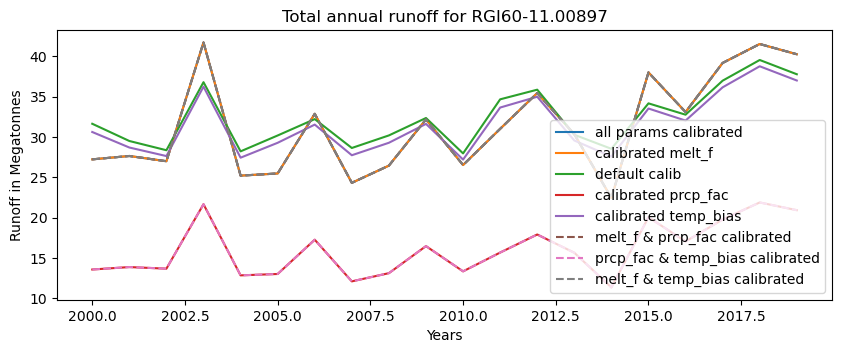

In [23]:
fig, ax = plt.subplots(figsize=(10, 3.5), sharex=True)
df_calib.sum(axis=1).plot(ax=ax, label='all params calibrated');
df_runoff_melt_f.sum(axis=1).plot(ax=ax, label='calibrated melt_f');
df_runoff.sum(axis=1).plot(ax=ax, label='default calib');
df_runoff_prcp_fac.sum(axis=1).plot(ax=ax, label='calibrated prcp_fac');
df_runoff_temp_bias.sum(axis=1).plot(ax=ax, label='calibrated temp_bias');
df_runoff_mf_pf.sum(axis=1).plot(ax=ax, label='melt_f & prcp_fac calibrated', linestyle='dashed');
df_runoff_pf_tb.sum(axis=1).plot(ax=ax, label='prcp_fac & temp_bias calibrated', linestyle='dashed');
df_runoff_mf_tb.sum(axis=1).plot(ax=ax, label='melt_f & temp_bias calibrated', linestyle='dashed');
plt.ylabel('Runoff in Megatonnes'); plt.xlabel('Years'); plt.title(f'Total annual runoff for {rgi_id}');
plt.legend();

The impact of calibrating different permutations of parameters can be seen above, this seems to impact the runoff result quite significantly depending on the calibration choices made! It can be seen that the rough shape is similar for all calibrations, but that different permutation of calibrating parameters can have a large impact on the amount of runoff predicted by the OGGM.

We can see that some of these runoff values are the same for certain calibrations, note that here that this is due to the style of calibration of our parameters, as we can see above the calibrations that calibrate `prcp_fac` first have a significantly lower runoff than the rest.

Now plotting the mass-balance results together and comparing this to the runoff outputs:

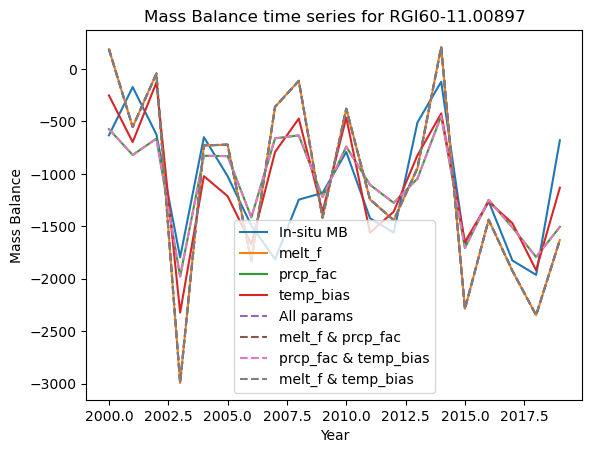

In [27]:
# Now plotting all the mass balance results together

# Adding the in-situ mass balance observations for comparison
mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

# The mass-balance from diffrent calibration runs throughout the tutorial
plt.plot(mbdf['in_situ_mb'], label='In-situ MB')
plt.plot(mbdf['melt_f_mb'], label='melt_f')
plt.plot(mbdf['prcp_fac_mb'], label='prcp_fac')
plt.plot(mbdf['temp_bias_mb'], label='temp_bias')
plt.plot(mbdf['calib_all_mb'], label='All params', linestyle='dashed')
plt.plot(mbdf['mf_pf_mb'], label='melt_f & prcp_fac', linestyle='dashed')
plt.plot(mbdf['pf_tb_mb'], label='prcp_fac & temp_bias', linestyle='dashed')
plt.plot(mbdf['mf_tb_mb'], label='melt_f & temp_bias', linestyle='dashed')
plt.legend()
plt.xlabel("Year")
plt.ylabel("Mass Balance");
plt.title(f'Mass Balance time series for {rgi_id}');

In this graph we can now see that our different calibrations also have an impact on the mass-balance

Here, we can see that there are a few overlaps again for different permutations of calibrations, if we look closely we can see that these are the same as the above for runoff.

However, from initial inspection we can see that for the runoff there is quite a significant difference based off of choices of calibrations. Here we can see that the differences between the mass-balance don't seem quite as dramatic.

From the runoff graph, the calibration of the `prcp_fac` appears to be impactful on the runoff. We can now explore a bit further, and investigate the relationship between `prcp_fac` and `melt_on_glacier`, which is a component of the `runoff`. We will do this by fixing the `prcp_fac` to a range of values and calibrating the `melt_f` to obtain a range of calibrated values. This will allow us to verify the sensitivity of these parameters.

## Sensitivity Analysis of runoff parameters in calibration

**Sensitivity Analysis** is a technique used to determine how a model output is affected by the changes in parameters. We will perform a simple sensitvity analysis in this tutorial to investigate the affects of parameter calibration on some of the runoff components.

We will now investigate the sensitivity of the runoff parameters to the calibration of the mass-balance parameters below. This will allow us to understand the relationship between parameters further, for example if one parameter is changed, how much does this affect the other parameter?

**First let's start with some definitions!**

We will be investigating the melt contribution, which is:
$ \frac{\text{melt on glacier}}{\text{runoff`}}$

In this tutorial we will investigate the sensitivities of the `melt_on_glacier` and melt contribution to the `prcp_fac`.

We have chosen these parameters as `melt_on_glacier` is a single variable, defined by a linear relationship from the `prcp_fac`. Here we will just be affecting the  `melt_on_glacier` directly.

The melt contribution variable is a bit more complicated, as this will be investigating the relationship between the run off which includes `melt_on_glacier` variable.

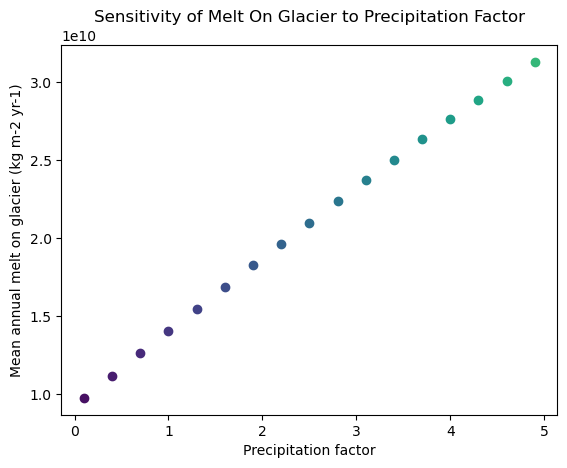

In [ ]:
# Varying prcp_fac between a range of values with a step of 1.0
pd_prcp_sens = pd.DataFrame(index=np.arange(0.1, 5.0, 0.3))
file_id = '_sens'

# Calibrate the melt factor for each precipitation factor
spec_mb_melt_f_sens_dict = {}
for pf in pd_prcp_sens.index:
    calib_param = mb_calibration_from_scalar_mb(gdir_hef,
                                  ref_mb = ref_mb,
                                  prcp_fac = pf,
                                  ref_period=cfg.PARAMS['geodetic_mb_period'],
                                  overwrite_gdir=True)

    # Fill the dataframe with the calibrated parameters
    pd_prcp_sens.loc[pf, 'melt_f'] = calib_param['melt_f']

    # We are using the task run_with_hydro to store hydrological outputs along with the usual glaciological outputs
    # Run this again with the calibrated parameters
    tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                        run_task=tasks.run_from_climate_data, # running from observed climate data
                        ys=2000,  # Period which we will average and constantly repeat
                        init_model_yr=2000, # Start from spinup year 2000
                        init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                        store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                        output_filesuffix=file_id);  # an identifier for the output file, to read it later

    with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds_sens:
        # The last step of hydrological output is NaN (we can't compute it for this year)
        ds_sens = ds_sens.isel(time=slice(0, -1)).load()

    # Plot the runoff again for the calibrated melt_f parameter
    sel_vars = [v for v in ds_sens.variables if 'month_2d' not in ds_sens[v].dims]
    df_annual_sens = ds_sens[sel_vars].to_dataframe()

    pd_prcp_sens.loc[pf, 'melt_off_glacier'] = df_annual_sens['melt_off_glacier'].mean()
    pd_prcp_sens.loc[pf, 'melt_on_glacier'] = df_annual_sens['melt_on_glacier'].mean()
    pd_prcp_sens.loc[pf, 'liq_prcp_off_glacier'] = df_annual_sens['liq_prcp_off_glacier'].mean()
    pd_prcp_sens.loc[pf, 'liq_prcp_on_glacier'] = df_annual_sens['liq_prcp_on_glacier'].mean()
    pd_prcp_sens.loc[pf, 'runoff'] = pd_prcp_sens.loc[pf, 'melt_off_glacier'] + pd_prcp_sens.loc[pf, 'melt_on_glacier'] + pd_prcp_sens.loc[pf, 'liq_prcp_off_glacier'] + pd_prcp_sens.loc[pf, 'liq_prcp_on_glacier']

colors_melt_f = plt.get_cmap('viridis').colors[10::10]
plt.figure()
for j, pf in enumerate(pd_prcp_sens.index):
    plt.plot(pf, pd_prcp_sens.loc[pf, 'melt_on_glacier'], 'o', color=colors_melt_f[j])
    plt.xlabel('Precipitation factor')
    plt.ylabel('Mean annual melt on glacier (kg m-2 yr-1)')
    plt.title('Sensitivity of Melt On Glacier to Precipitation Factor')

# Here we are varying the precipitation factor and calibrating the melt factor for each value
# Then plotting the mean annual melt_on_glacier against the precipitation factor

In the above plot, a strong linear positive correlation is shown between the precipitation factor and the mean annual melt on the glacier. 

From the calibration, it can be seen that as the precipitation factor is changed, the melt factor parameter is calibrated accordingly and increases with the precipitation factor to maintain the average annual mass-balance. Therefore as the `prcp_fac` increases, the `melt_on_glacier` increases linearly in a 1:1 ratio.

In the OGGM, the `melt_on_glacier` is derived from both the `melt_f` parameter and `prcp_fac`. Therefore this sensitivity makes sense.

Now investigating the sensitivity of the Glacier Melt Contribution to the Precipitation Factor.

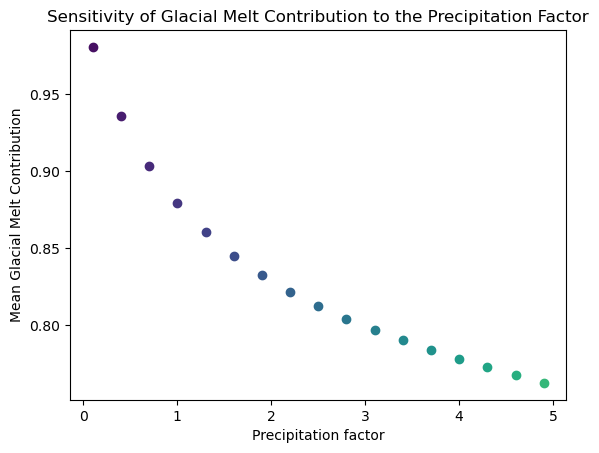

In [20]:
colors_melt_f = plt.get_cmap('viridis').colors[10::10]
plt.figure()
for j, pf in enumerate(pd_prcp_sens.index):
    plt.plot(pf, pd_prcp_sens.loc[pf, 'melt_on_glacier']/pd_prcp_sens.loc[pf, 'runoff'], 'o', color=colors_melt_f[j])
    plt.xlabel('Precipitation factor')
    plt.ylabel('Mean Glacial Melt Contribution')
    plt.title('Sensitivity of Glacial Melt Contribution to the Precipitation Factor')

# Here we are plotting how the glacial melt contribution (melt_on_glacier/runoff) varies with the changing precipitation factor
# This shows how the relative contribution of glacier melt to total runoff changes as we adjust precipitation

It can be seen that there is a relatively strong negative correlation, between the precipitation factor and the mean glacial melt contribution. And therefore it can be seen that the mean glacial melt contribution is sensitive to the change in precipitation factor. As we increase the `prcp_fac`, we know that the `melt_f` increases along with this. Considering the melt contribution variable contains a numerator of `melt_on_glacier`, which has been shown to increase as the `prcp_fac` parameter increases.

The denominator is the runoff, which contains 4 summed variables (including `melt_on_glacier`) that are affected by the `prcp_fac`, all of which increase as the `prcp_fac` increases, as can be seen within the OGGM model implementation. The runoff therefore increases at least as much as the `melt_on_glacier`.

Therefore the increase of the denominator overpowers the increase of the numerator, and the relationship shown above reflects this reaction to the increase in `prcp_fac`.

## Exercise:

Try this yourself for sensitivity with the precipitation factor when varying the melt factor as above:
1. The melt_off_glacier parameter.
2. The total liquid precipitation parameters (sum of on and off).
3. Any other interesting combinations you can discover!

Does anything you discover surprise you?
Are there particularly sensitive parameters compared to others?

**Stretch:** Can you experiment different combinations of parameters for sensitvity, e.g. such as varying the temp_bias parameters instead? 

## WGMS

In [21]:
# # We start by fetching the observations
# mbdf = gdir_hef.get_ref_mb_data()[['ANNUAL_BALANCE']]
# mbdf.columns = ['in_situ_mb']
# mbdf = mbdf.loc[2000:2019]
# mbdf.plot();
# mbdf.mean()